In [2]:
import numpy as np
import math as mt


# 1. Constante de Madelung
Utilizaremos las siguientes expresiones. \
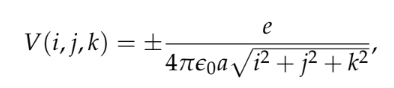 \
y\
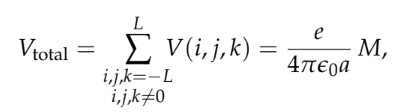

In [3]:
#Para hallar la constante de Madelung, despejamos la segunda expresión.
#el desarrollo de la dedución de M (constante de Madelung esta en notas de pdf.



In [4]:
#defino una funcion par o impar y si la suma de i+j+k es par entonces la función regresa 1 y si es impar regresa un -1
def paroimpar(i,j,k):
    if (i+j+k)%2 == 0:
        v = 1
    else:
        v = -1
    return v

In [5]:
#defino mi función Madelung que se encargara de darme la constante
def Madelung(L): 
    suma=0 #defino un valor auxiliar suma en 0
    for i in range(-L,L+1): #el rango de la suma en i
        for j in range(-L,L+1): #el rango de la suma en j
            for k in range(-L,L+1): #el rango de la suma en k
                if i == 0 and j==0 and k==0: #omitimos el caso i=j=k=0, que es estar en el origen que ya esta ocupado.
                    continue
                else: #Para todos los demas 
                    M = (paroimpar(i,j,k))/np.sqrt((i**2)+(j**2)+(k**2)) #expresión deducida en el pdf 
                    suma = suma + M # el valor de la constante depende de la suma, entonces guardamos todas las sumas de cada proceso.
    return suma #regresa suma que es la constante de madelung.


                    
                



In [23]:
Madelung(100)

np.float64(-1.7418198158396654)

In [6]:

L105 = Madelung(105)
print(L105)

-1.7530371090359904


In [7]:
Madelung(1)

np.float64(-2.1335207792784368)

## 2. Fórmula semiempírica de la masa (FSM)
![image.png](attachment:913ead68-b814-4675-a58a-cc8e769fefe6.png)

## inciso a

In [8]:
#Defino mis constantes a1 hasta a4.
a1= 15.8 
a2 = 18.3
a3= 0.714
a4=23.2
def energiaB(A,Z): #defino la función energiaB la cual me da la energia de enlace dependiendo del atomo que corresponda.
    "función para obtener la energía de enlace B, y es una función de 2 variables, donde la primera a introducir es A y la segunda es Z"
    a=A%2
    z=Z%2
    if a == 0: #tenemos 3 casos, comenzando por si A es par, entonces su residuo al dividir por 2, es cero. 
        if z == 0: # si Z es par entonces su residuo de dividir por 2, es cero, entonces a5 es igual a 12 
            a5=12
        else: #si no, en todo caso es impar y a5 es igual a -12
            a5=-12
    else: #Si A es impar, no importa el valor Z, y en automático a5 es igual a cero.
        a5=0

    b = a1*A - a2*np.pow(A,2/3) - a3*((Z**2))/np.pow(A,1/3) - a4*((A-2*Z)**2)/A + a5/np.sqrt(A) #La expresión para el calculo de B
    

    return b #nos regresa la energía de enlace dado A y Z

In [9]:
#Condición A=58 y Z=28
energiaB(58,28)

np.float64(497.5620206224374)

## inciso b
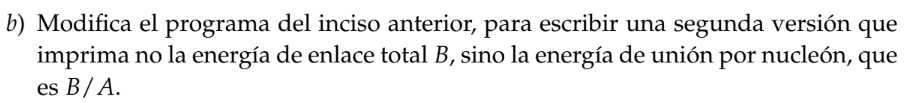

In [10]:
def nucleon(A,Z):
    "Función para obtener la energía de unión nucleón, y para ello llamamos a la función energiaB y la dividimos entre A"
    "Las variables de esta función son las mismas A y Z, introduciendolas en el mismo orden"
    N = energiaB(A,Z)/A #expresión de energía de unión por nucleón.
    return N

In [34]:
nucleon(58,28)

np.float64(8.578655527973059)

## Inciso c
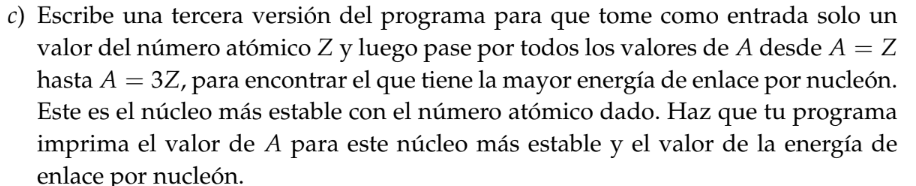

In [12]:
def Estable(Z):
    "Esta función permite saber cual es el nucleo más estable dado el número atomico"
    Mayor = 0 #defino a un valor llamado Mayor que representara la cantidad con mayor energía de enlace por nucleón.
    A_estable = 0 #defino mi valor A_estable que indica cual es el valor de A más estable dado el número atomico.
    for i in range (Z, 3*Z+1): #la función ejecuta un for que va de [Z,3Z] 
        A = i #A es igual a valores entre [Z,3Z]
        nucleon(A,Z) #llamo a la función nucleon para poder obtener cada una de las energías con A en [Z,3Z]
        if nucleon(A,Z) > Mayor: #Si Nucleon es mayor que Mayor, entonces.
            Mayor = nucleon(A,Z) #Cambiamos el Valor de Mayor por el valor de la función nucleon(A,Z) ejecutado
            A_estable = A #Cambiamos el Valor de A_estable por el valor de la A que nos produce el mayor valor de energia
    return Mayor, A_estable #finalizando la iteración nos regresa el valor de mayor energia de enlace por nucleon y su A correspondiente

        

In [39]:
#Imprimimos Estable para Z=28
Estable(28)

(np.float64(8.70245768367189), 62)

## inciso d
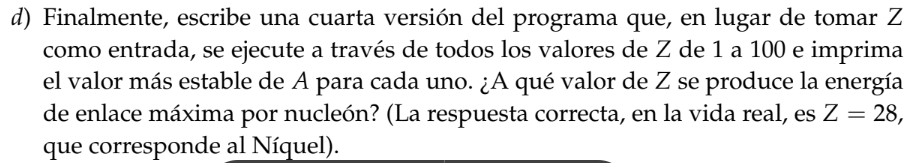

In [40]:
#Programa para imprimir el valor mas estable con Z de 1 a 100
def D1a100():
    "Función que nos arroja el valor más estable entre 1 a 100 números atomicos"
    Mayor_estable = 0 #Definimos el Mayor_estable que es el mayor valor de los estados estables
    for i in range (1,101): #for que va en un rango de [1,100]
        Z = i #Z va de 1 a 100
        E = Estable(Z)[0] #llamamos a la primera entrada de la función Estable(Z), que nos dice la energía por nucleón.
        if E > Mayor_estable: #Si E > Mayor_estable
            Mayor_estable = E #modifica el valor de Mayor_estable por E
            Ae = Estable(Z)[1] #definimos el A recordando que la segunda entrada de la función nos da el valor de A que se logra la maxima energía
            zeta = Z #Guardamos la Z mas estable como zeta
        A = Estable(Z)[1]
        print("Para Z =",Z, "su energia por nucleón es", E,"MeV y A =", A)
    print("El mayor valor estable para Z de 1 a 100 es: Z =",zeta,",", Mayor_estable, "su energía de unión por nucleón y", Ae,"su respectiva A")

In [41]:
D1a100()

Para Z = 1 su energia por nucleón es 0.36869091831015793 MeV y A = 3
Para Z = 2 su energia por nucleón es 5.321930578649441 MeV y A = 4
Para Z = 3 su energia por nucleón es 5.280168164356119 MeV y A = 7
Para Z = 4 su energia por nucleón es 6.466330085889912 MeV y A = 8
Para Z = 5 su energia por nucleón es 6.650123444727665 MeV y A = 11
Para Z = 6 su energia por nucleón es 7.200918138809924 MeV y A = 14
Para Z = 7 su energia por nucleón es 7.330860591990982 MeV y A = 15
Para Z = 8 su energia por nucleón es 7.719275577459026 MeV y A = 18
Para Z = 9 su energia por nucleón es 7.736977682756342 MeV y A = 19
Para Z = 10 su energia por nucleón es 8.035350864715019 MeV y A = 22
Para Z = 11 su energia por nucleón es 8.025554739665797 MeV y A = 25
Para Z = 12 su energia por nucleón es 8.241172535624845 MeV y A = 26
Para Z = 13 su energia por nucleón es 8.240988355754636 MeV y A = 29
Para Z = 14 su energia por nucleón es 8.37916169002579 MeV y A = 30
Para Z = 15 su energia por nucleón es 8.385214

# 3. Coeficiente binomial
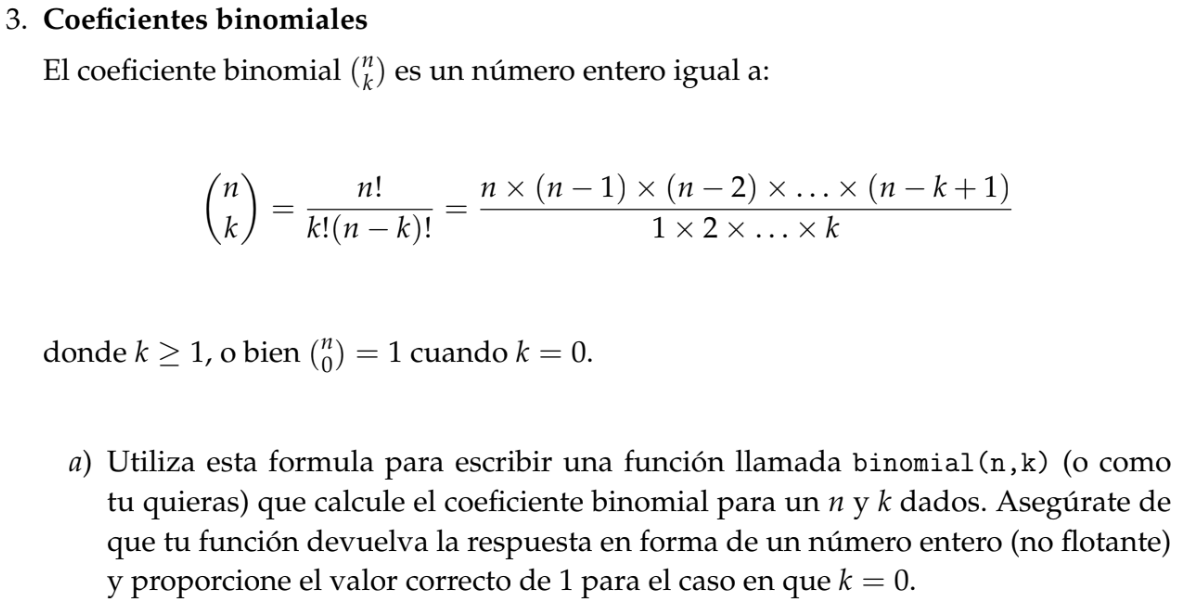

In [16]:
#construimos nuestra función binomial
def binomial(n,k):
    "función que nos permite encontrar el valor binomial, (n,k) a su vez solo permite enteros en ambas entradas y k => 0 pero k <= n"
    binomial = int(mt.factorial(n)/(mt.factorial(k)*mt.factorial(n-k))) #Tener la función factorial aplicada nos ayuda a no ejecurtar números negativos de k o k>n
    return binomial  
    

In [17]:
binomial(1,1)

1

b) imprimir las primeras veinte lineas del triangulo de Pascal.

In [18]:
#Primeras veinte lineas del triangulo de pascal
for n in range(1,21): #proponemos un for que va de 0 a 20, las lines del triangulo de pascal que queremos.
    k = 0 #defino k = 0, el número al que empieza los binomiales
    while k <= n: #mientras k sea menor o igual a n 
        print(binomial(n,k), end = " ") #imprime el binomial correspondiente, pero al terminar, solo es un espacion de separación.
        k += 1 #le sumamos 1 a k
    print() # despues de obtener todos los binomiales de alguna n del respectivo rango, antes de comenzar otro ciclo con una nueva n, nos da un salto de línea

1 1 
1 2 1 
1 3 3 1 
1 4 6 4 1 
1 5 10 10 5 1 
1 6 15 20 15 6 1 
1 7 21 35 35 21 7 1 
1 8 28 56 70 56 28 8 1 
1 9 36 84 126 126 84 36 9 1 
1 10 45 120 210 252 210 120 45 10 1 
1 11 55 165 330 462 462 330 165 55 11 1 
1 12 66 220 495 792 924 792 495 220 66 12 1 
1 13 78 286 715 1287 1716 1716 1287 715 286 78 13 1 
1 14 91 364 1001 2002 3003 3432 3003 2002 1001 364 91 14 1 
1 15 105 455 1365 3003 5005 6435 6435 5005 3003 1365 455 105 15 1 
1 16 120 560 1820 4368 8008 11440 12870 11440 8008 4368 1820 560 120 16 1 
1 17 136 680 2380 6188 12376 19448 24310 24310 19448 12376 6188 2380 680 136 17 1 
1 18 153 816 3060 8568 18564 31824 43758 48620 43758 31824 18564 8568 3060 816 153 18 1 
1 19 171 969 3876 11628 27132 50388 75582 92378 92378 75582 50388 27132 11628 3876 969 171 19 1 
1 20 190 1140 4845 15504 38760 77520 125970 167960 184756 167960 125970 77520 38760 15504 4845 1140 190 20 1 


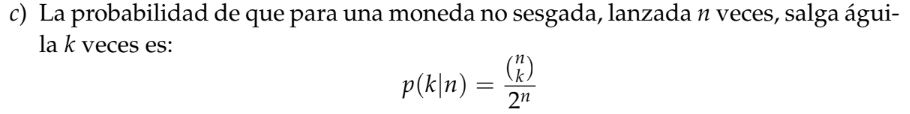

In [19]:
#Probabilidad de moneda no sesgada y exacta.
def moneda(n,k):
    "Probabilidad de obtener en n lanzamiento, k veces alguna cara de la moneda"
    proba = binomial(n,k)/(2**n) #formula de la probabilidad 
    return proba

### 1) la probabilidad total de que una moneda lanzada 100 veces, salga aguila exactamente 60 veces 

In [20]:
#para 100 lanzamiento y sacar 60 veces aguila
moneda(100,60)

0.010843866711637987

### 2) la probabilidad de que salga aguila 60 veces o más. 

In [21]:
#Para 100 lanzamientos y sacar 60 o más aguila
n = 100 #número de lanzamientos
k = 60 #primer evento al que queremos calcular probabilidad.
suma = 0 #valor auxiliar para la suma
while k <= n: #si queremos calcular por distintos intervalos, solo es necesario modificar el valor donde querememos calcular nuestra probabilidad como k < 80 por ejemplo.
    suma = suma + moneda(n,k) #como son eventos ajenos, la unión es la suma de las probabilidades de cada evento.
    k += 1 #sumamos 1 a k para que el while no falle.
print(suma)    

0.028443966820490392


# 4. Números primos

In [22]:
L = [2] #Comenzamos una lista con el primer primo que es 2.
N = 10000 #definimos hasta que numero queremos encontrar números primos
for i in range (3,N+1): #comenzamos a partir de 3 hasta N.
    primo = i #defino mi variable primo 
    no_es = False #defino mi condición boleana no es igual a false, o sea que por lo mientras si es (primo).
    for j in L: #un for que se mueva en la lista de números primos
        if j <= mt.ceil(mt.sqrt(i)): #si j es menor que el techo de la raiz de i (para que nos lleve a un entero) 
            multip = primo%j #entonces aplicamos una variable llamada multip que es el residuo de primo entre j
            if multip == 0: 
                no_es = True #si el multip == 0 entonces es verdad que no_es (primo).
                break
        else: #para los demas casos no nos interesa
            break
    if no_es == True: #como no es un primo, entonces continua y repite el for para la siguiente i
        continue
    else: #si no_es sigue siendo falso, entonces primo (la variable que definimos) si es primo y se agrega a la lista L
        L.append(primo)
print(L)    #imprime la lista

[2, 3, 5, 7, 11, 13, 17, 19, 23, 29, 31, 37, 41, 43, 47, 53, 59, 61, 67, 71, 73, 79, 83, 89, 97, 101, 103, 107, 109, 113, 127, 131, 137, 139, 149, 151, 157, 163, 167, 173, 179, 181, 191, 193, 197, 199, 211, 223, 227, 229, 233, 239, 241, 251, 257, 263, 269, 271, 277, 281, 283, 293, 307, 311, 313, 317, 331, 337, 347, 349, 353, 359, 367, 373, 379, 383, 389, 397, 401, 409, 419, 421, 431, 433, 439, 443, 449, 457, 461, 463, 467, 479, 487, 491, 499, 503, 509, 521, 523, 541, 547, 557, 563, 569, 571, 577, 587, 593, 599, 601, 607, 613, 617, 619, 631, 641, 643, 647, 653, 659, 661, 673, 677, 683, 691, 701, 709, 719, 727, 733, 739, 743, 751, 757, 761, 769, 773, 787, 797, 809, 811, 821, 823, 827, 829, 839, 853, 857, 859, 863, 877, 881, 883, 887, 907, 911, 919, 929, 937, 941, 947, 953, 967, 971, 977, 983, 991, 997, 1009, 1013, 1019, 1021, 1031, 1033, 1039, 1049, 1051, 1061, 1063, 1069, 1087, 1091, 1093, 1097, 1103, 1109, 1117, 1123, 1129, 1151, 1153, 1163, 1171, 1181, 1187, 1193, 1201, 1213, 1217, 12